# Homework 3: Download and analyze any data using tools you learned in class

### IMPORTANT: Save your notebook and files (if you import locally) 
### IMPORTANT: See my example data folder: data/hw/hw_3/cory-baird
### **HW Requirements**

- **Relative Paths Only**
  - Use relative paths from the project root (e.g., `data/hw/hw_3/student-name/data.csv`).
  - Never hardcode absolute paths specific to your local machine (e.g., `/Users/username/...`).
- **File Size Limit**
  - Any committed dataset must be reasonable in size (strictly under 10 megabytes).
    - If you have to filter the dataset (to make it smaller) and upload a smaller version

- **Dataset Selection**
  - Select a policy-relevant dataset with at least 50 observations (e.g., 50 states, countries, or time periods) for meaningful analysis.
  - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Data Acquisition**
  - You are highly encouraged to fetch data programmatically using an API (e.g. using `requests` with World Bank, US Census, or other public APIs) or load a direct public URL.

  - Alternatively, you may upload a local file, provided it is committed to your repository.
    - If you read csv/parquet etc use relative paths such as `data/hw/hw_3/student-name/data.csv`.
    - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Reproducibility**
  - Commit both this notebook and the dataset so that your grader can run all cells from top to bottom out-of-the-box.

## IMPORTANT

---
### **Objectives**
- Select, acquire, and load a policy-relevant dataset of your choice.
- Apply clean code principles (environment checks, Python collections, standardized variable naming).
- Preprocess and standardize columns using Pandas techniques.
- Programmatically merge your primary dataset with a secondary source.
- Segment your data and run custom aggregations (using groupby or custom grouping strategies).
- Create customized visualizations and run exploratory regression analysis to discover policy insights.

### **Concept Reference Map**
- **Data Acquisition**: APIs (`requests` library), reading Parquet/CSV (Week 2/3 basics, Week 4 `1-visualization_basics.ipynb`)
- **Data Manipulation**: Selecting, renaming columns, filtering (`query()`), dropping NaNs (Week 4 `1-visualization_basics.ipynb`)
- **Aggregation**: Groupby, descriptive statistics (`describe()`, `mean()`) (Week 4 `1-visualization_basics.ipynb`)
- **Data Merging**: Pandas `merge()` matching indices or keys (Week 4 `2-merging_practice.ipynb`)
- **Visualization**: Scatter plots, line/bar charts, customization (Week 4 / Week 6 `1-regression.ipynb`)
- **Modeling**: Simple Linear Regression (`statsmodels`), line of best fit (Week 6 `1-regression.ipynb`)

---

### **Part 1: Data Acquisition & Environment Preparation**

- **Environment Setup**
  - Use python's `os` library (as reviewed in Week 3) to print your current working directory (`os.getcwd()`) and list the files in your project directory (`os.listdir()`) to ensure your paths are configured correctly.
- **Acquisition Steps**
  - Programmatically fetch data using `requests` or read directly from a public URL using Pandas.
  - If loading a committed local dataset, load it using a relative path.
- **Code Requirements**
  - Define variables using standardized, descriptive names.
  - Keep all function and method arguments on a single line.
  - Do not use docstrings (`""" """`) or runtime type checking in your helper methods.

In [1]:
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt

print(f"Current working directory: {os.getcwd()}")
df = pd.read_csv("../../../data/hw/hw_3/V-Dem-CY-Core-v16.csv")

# You can use example datasets here docs/example_datasets.md

# 1. Print environment details (working directory and local folder contents)
# If you read csv/parquet etc use relative paths such as data/hw/hw_3/student-name/data.csv
# YOUR CODE HERE

# 2. Acquire and load your primary dataset
# YOUR CODE HERE

Current working directory: /Users/cyrusng/Documents/GitHub/datascience-publicpolicy-2026/notebooks/hw/hw_3


### **Dataset Context & Relevance**

- **Dataset Source**
  - Specify the source of your dataset (e.g., API name, public organization, or website URL).

- Source: The V-Dem Datatset: Country-Year: V-Dem Core version 16

### **Part 2: Data Cleaning & Preprocessing**

- **Data Inspection**
  - Inspect column names, data types, and non-null counts using `.info()` and `.head()`.
- **Preprocessing Tasks**
  - Select a subset of columns necessary for your policy inquiry.
  - Standardize column names to a clean formatting (preferably `snake_case` or another consistent style).
  - Identify and handle missing values (`NaN`s) by dropping or filling them.
- **Python Grammar Tip**
  - You are encouraged to use a Python dictionary (as reviewed in Week 2 & 3) to map and rename your column names cleanly.

In [2]:
# 1. Inspect data structure using pandas methods
# YOUR CODE HERE
df.info()
df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28092 entries, 0 to 28091
Columns: 1908 entries, country_name to v2edplural_nr
dtypes: float64(1891), int64(13), object(4)
memory usage: 408.9+ MB


,country_name,country_text_id,country_id,year,historical_date,project,historical,histname,codingstart,codingend,...,v2edplural_sd,v2edplural_osp,v2edplural_osp_codelow,v2edplural_osp_codehigh,v2edplural_osp_sd,v2edplural_ord,v2edplural_ord_codelow,v2edplural_ord_codehigh,v2edplural_mean,v2edplural_nr
0,Mexico,MEX,3,1789,1789-12-31,1,1,Viceroyalty of New Spain,1789,2025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Mexico,MEX,3,1790,1790-12-31,1,1,Viceroyalty of New Spain,1789,2025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Mexico,MEX,3,1791,1791-12-31,1,1,Viceroyalty of New Spain,1789,2025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Mexico,MEX,3,1792,1792-12-31,1,1,Viceroyalty of New Spain,1789,2025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Mexico,MEX,3,1793,1793-12-31,1,1,Viceroyalty of New Spain,1789,2025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# 2. Rename columns and select a clean subset
#  YOUR CODE HERE
df_2021 = df.query("year == 2021")[['country_name', 'year', 'v2x_polyarchy','v2x_libdem']].dropna()
df_2021.head(5)

,country_name,year,v2x_polyarchy,v2x_libdem
232,Mexico,2021,0.624,0.371
358,Suriname,2021,0.761,0.639
595,Sweden,2021,0.900,0.866
823,Switzerland,2021,0.896,0.851
947,Ghana,2021,0.659,0.554


In [4]:
# 3. Filter row or column filters if necessary
# YOUR CODE HERE
df_2021 = df_2021.rename(columns={'country_name': 'country', 
                                  'v2x_polyarchy': 'Electoral democracy index', 
                                  'v2x_libdem':'Liberal democracy index'})
df_2021.head(5)

,country,year,Electoral democracy index,Liberal democracy index
232,Mexico,2021,0.624,0.371
358,Suriname,2021,0.761,0.639
595,Sweden,2021,0.900,0.866
823,Switzerland,2021,0.896,0.851
947,Ghana,2021,0.659,0.554


In [5]:
# 4. Handle missing values (NaNs) if necessary
# YOUR CODE HERE
df_dem = df_2021.set_index("year")
df_dem.head(5)

,country,Electoral democracy index,Liberal democracy index
year,,,
2021,Mexico,0.624,0.371
2021,Suriname,0.761,0.639
2021,Sweden,0.900,0.866
2021,Switzerland,0.896,0.851
2021,Ghana,0.659,0.554


### **Part 3: Merging Datasets**

- **Secondary Source Selection**
  - Programmatically download/read another related dataset.
- **Clean & Standardize**
  - Preprocess and rename the columns of the secondary dataset.
- **Merging Process**
  - Merge both datasets on a common key (such as country code or year).
  - Display the shape and head of your merged dataset to verify that the join was successful.

In [6]:
# 1. Load and clean the secondary dataset
# YOUR CODE HERE
import requests
import pandas as pd

# Fetch the data
url = "https://www.imf.org/external/datamapper/api/v1/NGDPDPC"
response = requests.get(url)
data = response.json()

records = []
for country, years in data["values"]["NGDPDPC"].items():
    for year, value in years.items():
        records.append({
            "iso": country,
            "year": int(year),
            "value": value
        })

df_imf= pd.DataFrame(records)
df_imf.info()
df_imf.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10873 entries, 0 to 10872
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   iso     10873 non-null  object 
 1   year    10873 non-null  int64  
 2   value   10873 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 255.0+ KB


,iso,year,value
0,SDN,1980,486.908
1,SDN,1981,339.389
2,SDN,1982,239.807
3,SDN,1983,318.513
4,SDN,1984,375.019


In [7]:
import subprocess
subprocess.run(["pip", "install", "pycountry"])

import pycountry

def iso_to_name(iso):
    try:
        return pycountry.countries.get(alpha_3=iso).name
    except:
        return iso

df_imf["country"] = df_imf["iso"].apply(iso_to_name)
df_imf = df_imf.drop(["iso"], axis="columns").set_index("year").rename(columns={'value': 'GDP per capita'})
df_imf_2021 = df_imf.query("year == 2021")
df_imf_2021.head(5)

,GDP per capita,country
year,,
2021,772.131,Sudan
2021,356.063,Afghanistan
2021,6396.387,Albania
2021,4169.218,Algeria
2021,41806.876,Andorra


In [8]:
# 2. Merge your datasets on a common key
# YOUR CODE HERE
def set_index(df_dem, df_imf_2021):
    df_dem = df_dem.set_index(['country'])
    df_imf_2021 = df_imf_2021.set_index(['country'])
    return df_dem, df_imf_2021

df_dem_indexed, df_imf_indexed = set_index(df_dem.copy(), df_imf_2021.copy())

def merge_data(df_dem, df_imf_2021):
    # YOUR CODE HERE
    df_merge = pd.merge(
        df_dem,
        df_imf_2021,
        right_index=True,
        left_index=True,
        how='inner'
    )
    return df_merge

df_merged = merge_data(df_dem_indexed, df_imf_indexed)
df_merged.head()

,Electoral democracy index,Liberal democracy index,GDP per capita
country,,,
Mexico,0.624,0.371,10207.315
Suriname,0.761,0.639,4987.986
Sweden,0.900,0.866,60435.671
Switzerland,0.896,0.851,96895.469
Ghana,0.659,0.554,2445.187


### **Merge Verification**

- **Merge Key**
  - Describe the matching key you selected (e.g. country, state, year).
- **Observations Retained**
  - Specify how many matching rows were successfully kept after merging.

- *Write your merge details here*

### **Part 4: Aggregation & Groupby Analysis**

- **Aggregation Task**
  - Segment your indicators using `.groupby()` to calculate descriptive metrics (such as `.mean()`, `.median()`, `.min()`, or `.max()`) across different categories.
- **Backup Strategies (If your dataset does not have natural multiple groups)**
  - If your dataset consists of only continuous variables, choose one of these backup strategies:
    - **Binning**: Use `pd.cut()` to partition a continuous variable into groups (e.g. splitting GDP per capita into low, medium, and high income groups).
    - **Threshold Filtering**: Segment your dataset into two groups based on a threshold (e.g. countries with life expectancy > 75 vs. <= 75).
    - **Dictionary Mapping**: Create a custom Python dictionary (as reviewed in Week 2 & 3) mapping continuous features to custom categories, and map/merge it into your DataFrame to create groups.

In [9]:
df_merged['Electoral democracy index'].describe()

count    153.000000
mean       0.524301
std        0.253310
min        0.015000
25%        0.287000
50%        0.537000
75%        0.761000
max        0.915000
Name: Electoral democracy index, dtype: float64

In [10]:
df_merged['Liberal democracy index'].describe()

count    153.000000
mean       0.409980
std        0.259707
min        0.033000
25%        0.176000
50%        0.401000
75%        0.639000
max        0.882000
Name: Liberal democracy index, dtype: float64

In [11]:
# Apply groupby aggregation or implement one of the backup grouping strategies
# YOUR CODE HERE

df_merged['GDP per capita'].describe()

count       153.000000
mean      16740.875392
std       23792.659525
min         258.815000
25%        2208.691000
50%        6231.291000
75%       20181.834000
max      136190.678000
Name: GDP per capita, dtype: float64

In [12]:
df_imf_descriptive_bycountry = df_imf.groupby('country')['GDP per capita'].describe().sort_values('mean', ascending=False)
df_imf_descriptive_bycountry.head(5)

,count,mean,std,min,25%,50%,75%,max
country,,,,,,,,
Liechtenstein,32.0,169531.504688,49956.076043,81267.915,140932.70450,166692.3695,206188.94800,259928.886
Luxembourg,52.0,83881.329365,51417.905036,11984.326,39377.71925,86603.2170,121471.33625,175281.024
Switzerland,52.0,67804.576423,36979.465378,17272.919,40393.56300,58683.6590,89860.31275,148483.234
Norway,52.0,61956.087462,34134.191963,14855.521,28874.43950,69112.5200,94931.29850,112747.923
San Marino,28.0,60672.558821,11586.395035,43068.693,51010.19800,59920.8535,70640.92450,80909.003


- *Extra Credit: Write your economic or policy related interpretation here*
The countries with the highest average gdp growth rate are the countries that have relatively less developed, except China. This to a small extent confirms the Solow Convergence Theory in the sense that only countries with low output can experience high GDP growth rates. 

### **Part 5: Visualization & Regression Modeling**

- **Visualization Requirements**
  - Generate at least two fully customized, beautiful Matplotlib plots.
  - **Plot 1**: A bar chart or line chart showing aggregated subgroups from Part 4.
  - **Plot 2**: A scatter plot representing the relationship between two primary indicators.
  - **Customizations**: Make sure to customize titles, axis labels, gridlines, colors, and markers for a clean and readable style.
- **Exploratory Modeling**
  - Fit a simple linear regression using `statsmodels` (Level-Level, Log-Level, or Log-Log as discussed in Week 6) to model the policy relationship.
  - Plot the line of best fit directly over your scatter plot.
  - Print the summary table and interpret the slope coefficient.

In [13]:
# Plot 1: Customized bar chart or line chart of aggregated subgroups
# YOUR CODE HERE
df_imf_plot = df_imf_descriptive_bycountry['mean'].head(5).sort_values()
df_imf_plot

country
San Marino        60672.558821
Norway            61956.087462
Switzerland       67804.576423
Luxembourg        83881.329365
Liechtenstein    169531.504688
Name: mean, dtype: float64

Text(0.5, 1.0, 'Mean GDP per capita by country over time')

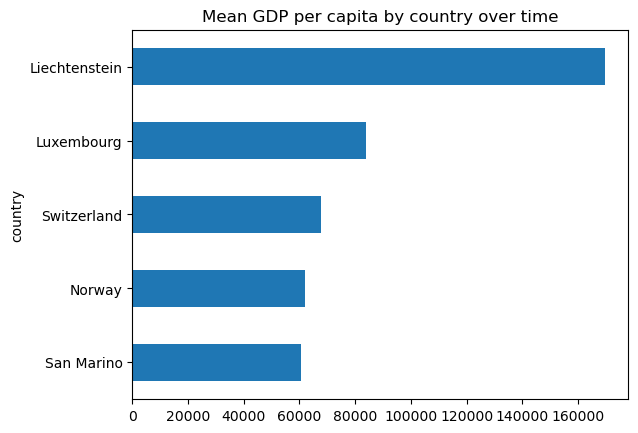

In [14]:
import matplotlib.pyplot as plt
df_imf_plot.plot(kind = 'barh')
plt.title("Mean GDP per capita by country over time")

<Axes: xlabel='country'>

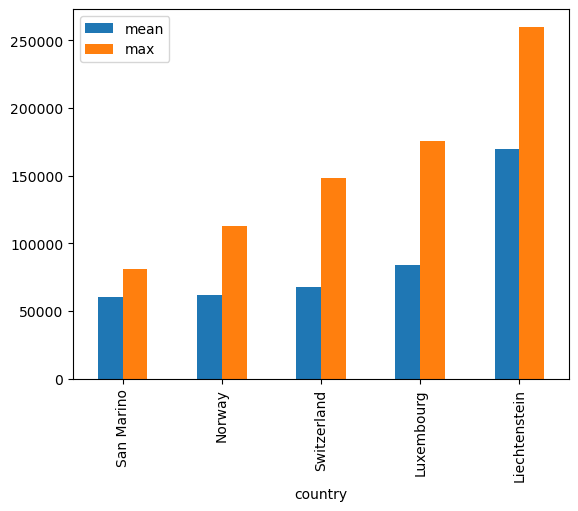

In [15]:
df_imf_descriptive_bycountry[['mean', 'max']].head(5).sort_values(by = 'mean').plot(kind = 'bar')

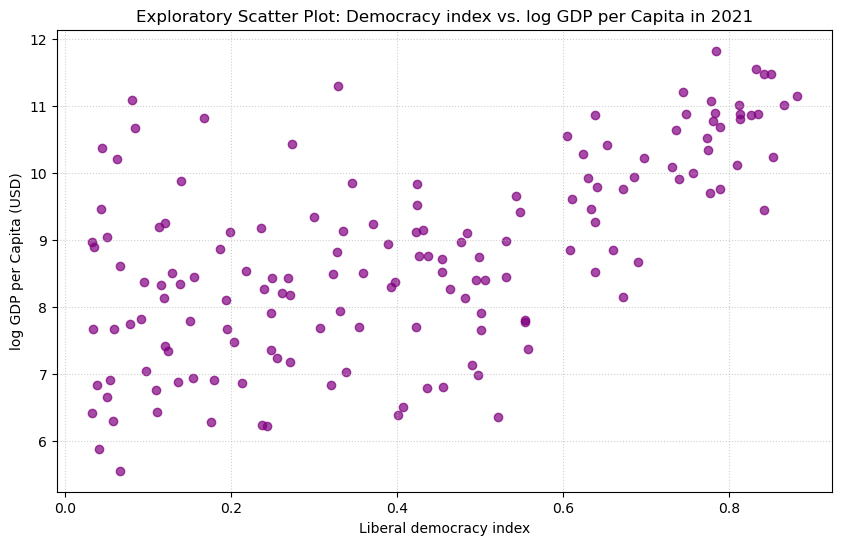

In [16]:
# Plot 2: Customized scatter plot of primary policy variables
# YOUR CODE HERE
import numpy as np
df_merged["log GDP per capita"] = np.log(df_merged["GDP per capita"])

plt.figure(figsize=(10, 6))
plt.scatter(x = df_merged['Liberal democracy index'], y =df_merged['log GDP per capita'], color='purple', alpha=0.7)
#the above is the most important part 

plt.title("Exploratory Scatter Plot: Democracy index vs. log GDP per Capita in 2021")
plt.ylabel("log GDP per Capita (USD)")
plt.xlabel("Liberal democracy index")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [17]:
# Fit a simple linear regression and overlay the line of best fit
# YOUR CODE HERE
import statsmodels.api as sm

X_real = df_merged['Liberal democracy index']
y_real = df_merged['log GDP per capita']
X_real_const = sm.add_constant(X_real)
model_real = sm.OLS(y_real, X_real_const).fit()
model_real

In [18]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

X = sm.add_constant(df_merged["Liberal democracy index"])
model = sm.OLS(df_merged["log GDP per capita"], X).fit()
b0, b1 = model.params.iloc[0], model.params.iloc[1]

x1 = df_merged["Liberal democracy index"].mean()
x2 = x1 + 0.1
y1 = b0 + b1 * x1
y2 = b0 + b1 * x2

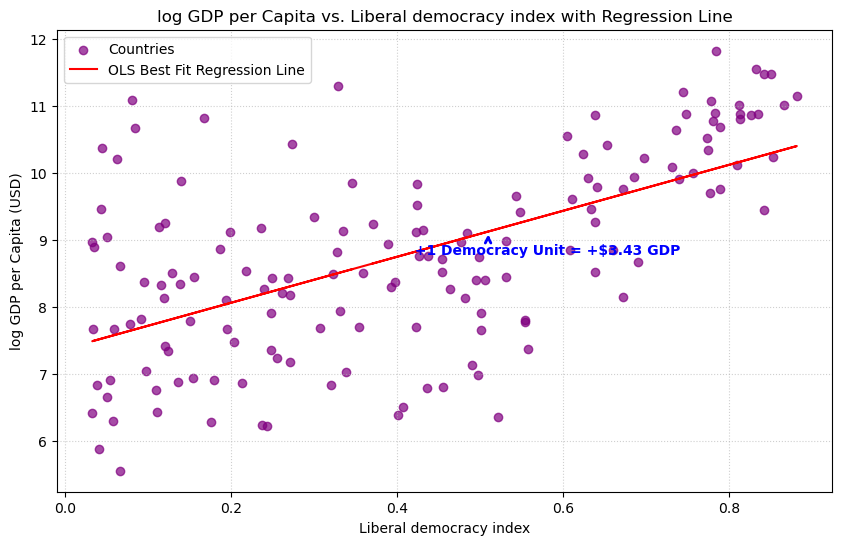

In [19]:
plt.figure(figsize=(10, 6))
plt.scatter(df_merged['Liberal democracy index'], df_merged['log GDP per capita'], color='purple', alpha=0.7, label='Countries')


plt.plot(df_merged["Liberal democracy index"], b0 + b1 * df_merged["Liberal democracy index"], color="red", label='OLS Best Fit Regression Line')
plt.annotate(f"  +1 Democracy Unit = +${b1:,.2f} GDP",xy=(x2, y2),xytext=(x1, y1),arrowprops=dict(arrowstyle="->", connectionstyle="angle,angleA=0,angleB=90", color="blue", lw=2),weight="bold",color="blue",)


plt.title("log GDP per Capita vs. Liberal democracy index with Regression Line")
plt.xlabel("Liberal democracy index")
plt.ylabel("log GDP per Capita (USD)")

plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

- *Extra Credit: Write your visualization and regression interpretations here*

In [20]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     log GDP per capita   R-squared:                       0.368
Model:                            OLS   Adj. R-squared:                  0.364
Method:                 Least Squares   F-statistic:                     88.07
Date:                Tue, 02 Jun 2026   Prob (F-statistic):           9.07e-17
Time:                        14:02:05   Log-Likelihood:                -240.09
No. Observations:                 153   AIC:                             484.2
Df Residuals:                     151   BIC:                             490.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [21]:
Regression interpretations:
- a logarithmic transformation is performed as GDP per capita is skewed to the right with countries like Luxemburg and Singapore pulling up the average despite a huge cluster of low income countries
- b1 = 3.43 implies that a country scoring 0.1 higher on democracy is associated with about 34% higher GDP per capita
- a p-value of 0.000 indicates the relationship is highly statistically significant

SyntaxError: invalid syntax (2883148761.py, line 1)

### **Submission Checklist**

- **Out-of-the-Box Execution**
  - Select `Kernel -> Restart & Run All` to verify all cells run without error.
- **Reproducibility & Paths**
  - Verify that both the notebook and the dataset are saved and committed in Git.
  - Ensure all files are loaded using relative paths.
- **Visual Elements & Design**
  - Ensure all plots are fully customized, clearly labeled, and have titles.